<table>
    <tr>
        <td><img src="https://s3.amazonaws.com/media-p.slid.es/uploads/1485763/images/9060062/Header.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:#6A0DAD;text-align:center"> <FONT COLOR="#6A0DAD"> Modelos de Regresión</FONT> </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Sesión 5</p></tp>
            <tp><p style="font-size:115%;text-align:center">11 de Abril 2026</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Daniel Rambaut </p></tp>
        </td>
    </tr>
</table>

En este notebook profundizaremos en el mundo de la **Regresión**. A diferencia de las sesiones anteriores donde buscábamos predecir categorías o etiquetas (clasificación), aquí nuestro objetivo será predecir **valores numéricos continuos** (como precios, temperaturas o ventas).
<br>
Aprenderemos sobre:
- la **Regresión Lineal Simple** (usando una sola variable para predecir)
- la **Regresión Lineal Múltiple** (usando múltiples variables)
- Cómo el modelo matemáticamente encuentra la mejor línea de predicción mediante **"Mínimos Cuadrados"**.
- Cómo evaluar qué tan buenas son nuestras predicciones usando métricas como el **Error Cuadrático Medio** (MSE) y el $R^2$.

---
# <FONT SIZE=5 COLOR="green"> 0. Repaso de la sesión anterior </FONT>

En la sesión pasada exploramos una de las herramientas más intuitivas y poderosas para clasificar datos: los **Árboles de Decisión**. Los conceptos clave fueron:

<FONT COLOR="green" SIZE=3>1. Árboles de Decisión:</FONT>  
Son modelos que toman decisiones basadas en reglas condicionales simples (como preguntas de "sí o no"), dividiendo los datos sucesivamente hasta llegar a una predicción final (hoja). Son excelentes porque son muy fáciles de interpretar.

<FONT COLOR="green" SIZE=3>2. Sobreajuste y Poda (Pruning):</FONT>
<br>
Vimos que si dejamos crecer un árbol sin límites, este termina "memorizando" los datos de entrenamiento (sobreajuste o *overfitting*), volviéndose incapaz de predecir casos nuevos. Para evitarlo, usamos la **poda**, que es como cortar las ramas innecesarias del árbol.

<FONT COLOR="green" SIZE=3>3. Pre-poda y Post-poda (CCP):</FONT>
<br>
La *pre-poda* restringe el crecimiento del árbol desde el principio (limitando su profundidad). La *post-poda* (usando el método CCP - Cost Complexity Pruning) deja que el árbol crezca por completo y luego elimina analíticamente las ramas que no aportan valor real a la predicción, encontrando el árbol óptimo.

---

# <FONT SIZE=5 COLOR="purple"> 1. Introducción </FONT>

**Modelo de regresión:** es el modelo en el que se busca establecer la relación entre un cierto número de características y una variable objetivo continua. Es decir, la relación entre la variable dependiente $y$ y las variables predictoras $x_1, x_2 , \dots , x_n$.



A continuación, definiremos las librerías necesarias para trabajar regresión

In [ ]:
# Para gráficos y data.frames
import pandas as pd
import numpy  as np

# librerías para graficar
import plotly.express     as px
import matplotlib.pyplot  as plt
import seaborn            as sns

# Widgets interactivos (sliders en las secciones 6 y 7)
import ipywidgets as widgets


# Dividir los datos entrenamiento y prueba
from sklearn.model_selection     import train_test_split
from sklearn.feature_selection   import RFE

# Para preprocesamiento: escalador
from sklearn.preprocessing       import StandardScaler

# Modelo de regresión
from sklearn.linear_model        import LinearRegression
from sklearn.svm                 import SVR
from sklearn.neighbors           import KNeighborsRegressor
from sklearn.tree                import DecisionTreeRegressor
from sklearn.ensemble            import RandomForestRegressor

# Métricas
from sklearn                     import metrics
from sklearn.metrics             import mean_squared_error, r2_score

# warnings
import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Sistema de autoevaluación</p>

A lo largo del notebook encontrarás ejercicios donde completas código y seleccionas una respuesta (`"a"`, `"b"`, `"c"`...) o calculas un valor. Usa la función `verificar()` para saber al instante si acertaste.

Ejecuta la siguiente celda **una sola vez, al principio**; no necesitas entender cómo está construida.

</div>

In [ ]:
# ============================================================
#  Sistema de autoevaluación — ejecútala una sola vez
# ============================================================
import hashlib

_banco_respuestas = {}

def _hash(s):
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def _registrar(id_preg, hash_correcto, tipo="texto", precision=None, pista=None):
    _banco_respuestas[id_preg] = {"hash": hash_correcto, "tipo": tipo, "precision": precision, "pista": pista}

def verificar(id_preg, respuesta):
    """Verifica tu respuesta para el ejercicio indicado por id_preg."""
    info = _banco_respuestas.get(id_preg)
    if info is None:
        print(f"No reconozco el ejercicio '{id_preg}'.")
        return

    if info["tipo"] == "numero":
        try:
            texto = f"{float(respuesta):.{info['precision']}f}"
        except (TypeError, ValueError):
            print("Esa respuesta no parece un número. Intenta de nuevo.")
            return
    else:
        texto = str(respuesta).strip().lower()

    ok = _hash(texto) == info["hash"]

    if ok:
        print("Correcto.")
    else:
        msg = "Incorrecto, intenta de nuevo."
        if info["pista"]:
            msg += f" Pista: {info['pista']}"
        print(msg)

# ---- Banco de respuestas (solo hashes, no revelan la respuesta) ----
_registrar("ident_1", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="Predecir un precio es un numero continuo, no una categoria.")
_registrar("ident_2", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Predecir si un cliente compra o no es una etiqueta (si/no), no un numero continuo.")
_registrar("ident_3", "3e23e8160039594a33894f6564e1b1348bbd7a0088d42c4acb73eeaed59c009d", tipo="texto", precision=None, pista="La temperatura de manana es un numero continuo.")
_registrar("rf_diagrama_a", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Cada arbol se entrena con una muestra distinta (bootstrap), por eso varian entre si.")
_registrar("rf_diagrama_b", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Promediar varias curvas ruidosas cancela parte del ruido individual de cada una.")
_registrar("rf_detective", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Busca los puntos mas lejos de la linea diagonal y=x en el grafico.")
_registrar("rf_importancia_top", "a8dd683b35dad0195b872c88ee181e6eb722d336963749675785f1f2b499c8e6", tipo="texto", precision=None, pista="Es la variable con mayor barra en el grafico de importancia.")
_registrar("svr_margen_a", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Los vectores de soporte son los puntos mas cercanos al limite del margen/tubo.")
_registrar("svr_margen_b", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Un C muy grande deja casi nulas violaciones al margen, ajustandose mucho a cada punto de entrenamiento.")
_registrar("svr_epsilon_a", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="Un tubo mas ancho (epsilon grande) tolera mas error antes de penalizar, por eso quedan menos vectores de soporte.")
_registrar("svr_epsilon_b", "51f26d4ebba803d33972aa49a7bac83240685e7a84b68c18d7c50b06586d53cc", tipo="numero", precision=1, pista="Revisa el R2 con epsilon=2.0 en la tabla que generaste.")
_registrar("svr_bug_diagnostico", "ca978112ca1bbdcafac231b39a23dc4da786eff8147c4e72b9807785afee48bb", tipo="texto", precision=None, pista="SVR usa distancias (kernel), y una variable en una escala mucho mayor domina el calculo si no se escala.")
_registrar("svr_bug_mejora", "2e7d2c03a9507ae265ecf5b5356885a53393a2029d241394997265a1a25aefc6", tipo="texto", precision=None, pista="Compara el R2 de prueba antes y despues de escalar.")
_registrar("comparacion_mejor", "18ac3e7343f016890c510e93f935261169d9e3f565436429830faf0934f4f8e4", tipo="texto", precision=None, pista="Es el modelo con mayor R2 de prueba en tu tabla final.")

print("Sistema de autoevaluación listo.")


# <FONT SIZE=5 COLOR="purple"> 2. Conceptos básicos de Machine Learning: Regresión </FONT>

En está sección revisaremos algunos conceptos básicos de regresión en  machine learning.

<FONT SIZE=3 COLOR="green"> a. Algoritmos de regresión: </FONT>  técnicas de aprendizaje supervisado para hacer predicciones sobre una variable objetivo $\mathbf{y}$ que es numérica continua, es decir, toma valor en un intervalo.


<center><FONT SIZE=4 COLOR="BLUE">Situación 1: Predicción ventas </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/ef2f70be5b4059198fa6d856ae1ad0b9802960df/supervisado4.png?raw=true" alt="centered image" width="500" height="250"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><FONT SIZE=4 COLOR="BLUE">Situación 2: Predicción precio apartamento </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/34ca9d1b545bc223a6505754189ac5499fdbc560/intro_regresion_1.jpg?raw=true" alt="centered image" width="500" height="250"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=3 COLOR="green"> b. Variable Objetivo: </FONT> también denominada **variable de respuesta**. En un algoritmo de aprendizaje de máquina supervisado, es la variable que queremos predecir (por lo general, denotada como $\mathbf{y}$).
<br>

<FONT SIZE=3 COLOR="green"> c. Variable(s) Predictora(s): </FONT> también denominada ***features*** o características, son las variables que se usarán para predecir la variable objetivo. Estas se denotan como

$$\mathbf{X}=\{X_1,X_2, \dots, X_n \}$$

<br>

<FONT SIZE=3 COLOR="green"> d. Conjunto de Entrenamiento: </FONT> es el subconjunto de registros que se selecciona para entrenar el modelo. Este conjunto consta de dos partes:

- $X_{train}$ : conjunto de entrenamiento de los predictores o *features*.

- $y_{train}$: conjunto de entrenamiento de la variable objetivo asociada al conjunto $X_{train}$.

El conjunto de entrenamiento se selecciona de manera aleatoria y por lo general se toma el $70\%$ , $75\%$ y $80 \%$.

<br>

<FONT SIZE=3 COLOR="green"> e. Conjunto de Prueba: </FONT>: Es el subconjunto de registros que se selecciona para validar el modelo. Consta de dos partes:

- $X_{test}$ : conjunto de validación de los predictores o *features*.

- $y_{test}$: conjunto de validación de la variable objetivo asociada al conjunto $X_{test}$.

El tamaño de este conjunto es el complemento del conjunto de entrenamiento.

**Nota:** para algoritmos clásicos de machine learning se acostumbra dividir en entrenamiento y prueba. Sin embargo, en algoritmos más complejos que requieren el entrenamiento de mucho parámetros, como es el caso de las redes neuronales, se acostumbra dividir en tres partes: *train* , *validation* and *test*.

<center><FONT SIZE=4 COLOR="BLUE"> Esquema general de modelos supervisados en Machine Learning </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/209c0394fc9518a5c7331d550d5606bf355c5707/esquema_modelos.jpg?raw=true" alt="centered image" width="700" height="500"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=4 COLOR="blue"> Algunos modelos de regresión </FONT>

Dentro de la bateria de modelos usados para regresión tenemos

1. Regresión lineal simple.

2. Regresión lineal múltiple

3. knn (k-vecinos más cercanos)

4. Árboles de Decisión

5. SVR: máquina de vectores de soporte para regresión

6. Random Forest


## <FONT SIZE=4 COLOR="blue"> 2.1. Ejercicios — Conceptos Básicos </FONT>


<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Antes de responder — chequeo rápido</p>

Clasifica cada situación como `a) Clasificación` o `b) Regresión`:

1. Predecir el **precio** de un apartamento según sus metros cuadrados.
2. Predecir si un **cliente va a comprar o no** un producto (sí/no).
3. Predecir la **temperatura máxima** de mañana en grados.

</div>

In [ ]:
respuesta_ident_1 = "?"   # a o b
respuesta_ident_2 = "?"   # a o b
respuesta_ident_3 = "?"   # a o b

verificar("ident_1", respuesta_ident_1)
verificar("ident_2", respuesta_ident_2)
verificar("ident_3", respuesta_ident_3)


### <FONT SIZE=3 COLOR="blue"> Ejercicio 1 </FONT>
Imagina que trabajas para una empresa de retail. Da un ejemplo de un problema de negocio que se resolvería con Clasificación y otro problema que se resolvería con Regresión. Justifica tu respuesta entendiendo la diferencia en la "Variable Objetivo".


*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
En el sector inmobiliario, si queremos predecir el precio de alquiler de una oficina, lista al menos 4 variables que considerarías como "Variables Predictoras ($X$)". ¿Por qué crees que son importantes para definir el valor objetivo ($y$)?


*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="blue"> Ejercicio 3 </FONT>
A lo largo de este notebook usaremos un dataset de apartamentos. Tu tarea es cargar este dataset (que dejaremos en la variable `url`), visualizar las primeras 5 filas y mostrar el tipo de datos de cada columna para identificar nuestras posibles variables predictoras numéricas.

In [ ]:
# URL del dataset de prueba
url = "https://raw.githubusercontent.com/drambaut/APRENDIZAJE-AUTOMATICO-DE-MAQUINA-I-/refs/heads/main/datasets/Apartamentos.csv"

# TU CÓDIGO AQUÍ
# 1. Carga los datos usando pd.read_csv()
aptos = ...
# 2. Muestra las primeras 5 filas
# 3. Usa el método .dtypes o .info() para ver los tipos de variables

if aptos is Ellipsis:
    raise ValueError(
        "Todavía no completaste esta celda: falta cargar el dataset con "
        "pd.read_csv(url) en la variable 'aptos'. El resto del notebook depende de ella."
    )


# <FONT SIZE=5 COLOR="purple"> 3. Modelo de Regresión Lineal Simple </FONT>

En este notebook iniciaremos explicando cómo funciona el modelo de **regresión lineal simple**, para ellos daremos una introducción a dos conceptos muy usados:
**covarianza** y **coeficiente de correlación**.









## <FONT SIZE=4 COLOR="green"> 3.1 Covarianza </FONT>

La covarianza es el valor que refleja en que medida dos variables aleatorias varian de forma conjunta respecto a sus medias.

De acuerdo con lo anterior, la covarianza está dada por la siguiente fórmula

$$Muestra: Cov(X,Y)=S_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{n-1}$$

$$Poblacion:COV(X,Y)=\sigma_{XY}=\dfrac{\sum \limits_{i=1}^N (x_i-\mu_x)(y_i-\mu_y)}{N}$$

donde $\overline{x}$ y $\overline{y}$ son las medias de las variables $X$ y $Y$ respectivamente y $n$ es el total de observaciones.

A continuación listaremos algunas propiedades de la covarianza

- $Cov(X,c)=0$, donde $c$ es una constante.

- $Cov(X,X)=Var(X)$, la covarianza de una variable con si misma es la varianza de la variable.

- $Cov(X,Y)=Cov(Y,X)$, la varianza es simétrica, es decir, no importa el orden en que se coloquen la variables.

- La covarianza mide la fuerza de la relación lineal entre dos variables.

- Una alta covarianza no implica efecto causal.

**Interpretación de la covarianza**

- $Cov(X,Y)>0$ ; las variables $X$ y $Y$ tienden a moverse en la misma dirección.

- $Cov(X,Y)<0$   las variables $X$ y $Y$ tienden a moverse en direcciones opuestas.

- $Cov(X,Y)=0$: las variables $X$ y $Y$ no estan relacionadas linealmente.

<br>
<center><img src="https://virtual.uptc.edu.co/ova/estadistica/docs/libros/ftp.bioestadistica.uma.es/libro/img456.gif" alt="centered image" width="600" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://virtual.uptc.edu.co/ova/estadistica/docs/libros/ftp.bioestadistica.uma.es/libro/node38.htm</FONT> <figcaption></center>
<br>

## <FONT SIZE=4 COLOR="green"> 3.2 Coeficiente de Correlación </FONT>

El coeficiente de correlación se define como

$$muestra: r_{xy}=\dfrac{S_{xy}}{S_xS_y} \qquad \qquad poblacion : \rho_{xy}=\dfrac{\sigma_{xy}}{\sigma_{x}\sigma_{y}}$$

lo que es equivalente a

$$r_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{\left (\sum \limits_{i=1}^n (x_i-\overline{x})^2 \right)^{1/2} \left ( \sum \limits_{i=1}^n (y_i-\overline{y})^2 \right)^{1/2}}$$

Veamos la interpretación de los diferentes valores del coeficiente de correlación de Pearson, teniendo en cuenta que:

$$-1 \leq r_{xy} \leq 1 $$

- Si $r_{xy}=1$, hay una relación positiva perfecta, es decir, indica una dependencia total entre las variables de manera directa. Si una de ellas aumenta, la otra también lo hace en proporción constante. Es decir, la relación es lineal.

- Si $0<r_{x,y}<1$, existe una correlación positiva.

- Si $r_{x,y}=0$, no existe relación lineal. Pero pueden haber otro tipo de relaciones.

- Si $-1<r_{x,y}<0$, existe una correlación negativa.

- Si $r_{x,y}=-1$, existe una correlación negativa perfecta, es decir, indica una dependencia total de manera inversa. Si una variable disminuye la otra aumenta en proporción constante.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/da5b836cf8bee14fa8ca4ffa3e53dd97c41136ea/regresi%C3%B3n4.png?raw=true" alt="centered image" width="800" height="800"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<br>
<center><img src="https://static.platzi.com/media/user_upload/tablita-5e6d38e8-8b72-4f20-9c17-8bfa7e11259b.jpg" alt="centered image" width="500" height="250"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://platzi.com/blog/coeficiente-de-correlacion-que-es-y-para-que-sirve/  </FONT> <figcaption></center>
<br>

Algunas propiedades para tener en cuenta del coeficiente de correlación:

- No depende de las unidades de las variables.

- El coefiente de Pearson es acotado





## <FONT SIZE=4 COLOR="green"> 3.3 Modelo de regresión lineal simple </FONT>

Supongamos que tenemos dos variables cuantitativas, que representan en el plano un conjunto de puntos $(x,y)$. En general, estos puntos no tienen porque estar ajustados de forma lineal, es decir, el diagrama de dispersión no tiene porque representar una recta.

Sin embargo, existen situaciones en que los puntos se aproximan o se ajustan en mayor medida a una línea recta. Particualmente cuando el coeficiente de correlación es cercano a 1 o a -1.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Regresi%C3%B3n/regresion1.png?raw=true" alt="centered image" width="550" height="300"></center>
<br>

La idea es encontrar una recta que se aproxime a los puntos dados

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/Regresi%C3%B3n/regresion2.png?raw=true" alt="centered image" width="550" height="300"></center>
<br>

Para hallar la ecuación de la recta que se observa en el gráfico se puede usar:

- Método de los mínimos cuadrados.

- Descenso del gradiente

<FONT SIZE=4 COLOR="blue"> Mínimos Cuadrados </FONT>

El método de los mínimos cuadrados permite hacer una estimación del modelo de regresión lineal simple.

Buscamos una recta de la forma

$$\hat{y}= \hat{\beta_0}+\hat{\beta_1}x$$

El método de mínimos cuadrados consiste en minimizar las sumas de los cuadrados de los errores $(SSE)$:

$$SSE=\sum \limits_{i=1}^n e_{i}^2= \sum \limits_{i=1}^n (y_{i}-\hat{y_i})^2$$

Esta expresión es la suma de las distancias al cuadrado entre los valores $y_i$ de la muestra (conjunto de datos) y los valores ajustados $\hat{y_i}$.

$$SSE(\hat{\beta_0},\hat{\beta_1})=\sum \limits_{i=1}^n (y_{i}-\hat{\beta_0}-\hat{\beta_1}x_i)^2$$

El objetivo de los mínimos cuadrados es hallar los valores de $\hat{\beta}_0$ y $\hat{\beta}_1$ que minimicen la expresión anterior. Para esto, realizaremos el procedimiento clásico para minimizar una función de dos variables y por tanto, derivamos parcialmente con respecto a los parámetros $\hat{\beta_0}$ y $\hat{\beta_1}$ e igualamos a cero.

$$\dfrac{\partial (SSE)}{\partial \hat{\beta}_0} = -2 \sum \limits_{i=1}^n (y_{i}-\hat{\beta}_0-\hat{\beta}_1x_i)$$
$$ \dfrac{\partial (SSE)}{\partial \hat{\beta_1}} = -2 \sum \limits_{i=1}^n (y_{i}-\hat{\beta_0}-\hat{\beta_1}x_i)x_i$$

el procedimiento que sigue se le deja al lector. Al igualar a cero y despejar $\hat{\beta_0}$ y $\hat{\beta_1}$ se obtiene:

$$\hat{\beta_0}= \dfrac{\sum \limits_{i=1}^n y_i - \hat{\beta}_1 \sum \limits_{i=1}^n x_i}{n}=\overline{y}-\hat{\beta_1}\overline{x} $$
$$\hat{\beta_1}=\dfrac{\sum \limits_{i=1}^n (x_i- \overline{x})(y_i-\overline{y})}{\sum \limits_{i=1}^n(x_i -\overline{x})^2}= \dfrac{S_{xy}}{S_{xx}}$$


donde, $S_{xy}$ es la covarianza muestral entre $X$ y $Y$.





## <FONT SIZE=4 COLOR="blue"> 3.3.1 Ejercicios — Covarianza, Correlación y Mínimos Cuadrados </FONT>


### <FONT SIZE=3 COLOR="blue"> Ejercicio 1</FONT>
Si calculamos el coeficiente de correlación de Pearson entre los metros cuadrados $mt^2$ de un apartamento y su `precio`, y obtenemos un valor de 0.85, ¿Cómo le explicarías este resultado a un cliente que no sabe de estadística?


*Escribe tu respuesta aquí:*



### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
La fórmula de "Mínimos Cuadrados" puede verse compleja, pero su propósito es sencillo. En tus propias palabras, ¿Qué es exactamente el "error" que esta fórmula está tratando de hacer lo más pequeño posible? (Piensa en la relación entre los puntos reales y la línea que dibujamos).


*Escribe tu respuesta aquí:*


## <FONT SIZE=5 COLOR="purple"> 3.4 Evaluación de un modelo de regresión </FONT>

En esta sección revisaremos la forma en que se evalúa un modelo de regresión.

***MSE : Error cuadrático medio***

Matemáticamente, el $MSE$ se puede calcular como la suma promedio de la diferencia al cuadrado entre el valor real y el valor previsto o estimado representado por el modelo de regresión (línea o plano).

<center><img src="https://github.com/Fabian830348/cursos/blob/master/Regresi%C3%B3n/mse.jpg?raw=true" alt="MSE" width="700"></center>


***$R^2$ coeficiente de determinación***

$R^2$ es la relación entre la regresión de suma de cuadrados (SSR) y la suma de cuadrados total (SST).

$$R^2 = \dfrac{SSR}{SST}= \dfrac{\sum \limits_{i=1}^{n} (\hat{y_i}-\overline{y})^2}{\sum \limits_{i=1}^{n} (y_i - \overline{y})^2}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/f8b630f3ce112dc8d05c828d9b5d3ac328c9544f/Imagen/reg2.png?raw=true" alt="centered image" width="500" height="300"></center>

La regresión de suma de cuadrados (SSR) representa la variación total de todos los valores pronosticados encontrados en la línea o plano de regresión del valor medio de todos los valores de las variables de respuesta. La suma de los cuadrados totales $SST$ representa la variación total de los valores reales del valor medio de todos los valores de las variables de respuesta.

El valor $R^2$ se utiliza para medir la bondad de ajuste o la línea de mejor se ajusta. Cuanto mayor sea el valor de $R^2$, mejor será el modelo de regresión, ya que la mayor parte de la variación de los valores reales a partir del valor medio queda explicada por el modelo de regresión.

**NOTA**

En regresión lineal se recomienda utilizar $R^2$ para evaluar el rendimiento del modelo de los modelos de regresión. Esto se debe principalmente a que $R^2$  captura la fracción de varianza de los valores reales capturados por el modelo de regresión y tiende a brindar una mejor imagen de la calidad del modelo de regresión. Además, los valores de $MSE$ difieren en función de si los valores de la variable de respuesta están escalados o no. Una mejor medida en lugar de MSE es el error cuadrático medio (RMSE) que se ocupa del hecho relacionado con si los valores de la variable de respuesta están escalados o no.

**CONCLUSIONES**

- $MSE$ representa el error residual que no es más que la suma de la diferencia al cuadrado entre los valores reales y los valores previstos/estimados divididos por el número total de registros.

- $R^2$ representa la fracción de varianza capturada por el modelo de regresión.

- La desventaja de usar $MSE$ es que este valor varía en función de si los valores de la variable de respuesta están escalados o no. Si está escalado, el MSE será más bajo que los valores no escalados.

## <FONT SIZE=4 COLOR="blue"> 3.4.1 Ejercicios — Evaluación del Modelo </FONT>


### <FONT SIZE=3 COLOR="blue"> Ejercicio 1 </FONT>
Acabas de presentar un modelo a la gerencia para predecir precios. Alguien te pregunta: *"¿Por qué usas el Error Cuadrático Medio (MSE) en lugar de simplemente promediar los errores normales sin elevarlos al cuadrado?"* ¿Cuál es la justificación matemática y práctica de elevar al cuadrado las diferencias?


*Escribe tu respuesta aquí:*



### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
Si un modelo de regresión obtiene un $R^2$ de 0.92, y otro modelo obtiene un $R^2$ de 0.35, ¿cuál de los dos modelos confiarías más para tomar decisiones financieras y por qué? ¿Qué significa ese 0.92 en términos del negocio?

*Escribe tu respuesta aquí:*

# <FONT SIZE=5 COLOR="purple"> 4. Ejemplo: Modelo de Regresión Lineal Simple </FONT>

Para este ejemplo consideraremos el conjunto de datos de apartamentos y las variables *precio* y *mt2*

Revisamos rápidamente algunos elementos de los datos

In [ ]:
aptos.head()

Eliminaremos la primera columna

In [ ]:
aptos.drop("Unnamed: 0" ,
           axis = 1 ,
           inplace = True)
aptos.head(5)

In [ ]:
# tamaño de los datos
aptos.shape

Descripción estadística general de los datos

In [ ]:
aptos.describe()

Alguna información general
  

In [ ]:
aptos.info()

Observe, que no tiene datos faltantes. Vamos a revisar la correlación de las variables cuantitativas de la base *aptos*.

- Para esto usamos el método  ***.corr( )***

In [ ]:
aptos.corr(numeric_only = True)

Observamos una fuerte correlación en las variables *precio* y *mt2*. Con coeficente de 0.858258

También podemos calcular la correlación de dos variables

In [ ]:
np.corrcoef(aptos.precio, aptos.mt2)[0,1]

Ahora, revisaremos el diagrama de dispersión.

In [ ]:
px.scatter(x= aptos.mt2,
           y= aptos.precio,
           color_discrete_sequence = ["purple"],
           labels = {"x" : "mt2", "y" : "precio"})

Revisemos los nombres de las columnas del data.frame

In [ ]:
aptos.columns

Para hacer el modelo, vamos a dividir los datos en variable de respuesta.

In [ ]:
# seleccionamos las variables (pero pilas que el modelo tiene lios con el tipo de elemento: series)
X = aptos.mt2
y = aptos.precio

In [ ]:
# variables predictoras y variable objetivo
X = pd.Series.to_frame(aptos.mt2)
y = pd.Series.to_frame(aptos.precio)

In [ ]:
# conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 1 ,
                                                    test_size = 0.2)

Generamos el modelo

In [ ]:
# modelo de regresión
modelo_rl = LinearRegression()

In [ ]:
# entrenamos el modelo
modelo_rl.fit(X_train, y_train)

In [ ]:
# revisamos los coeficientes
print(modelo_rl.coef_)
print(modelo_rl.intercept_)

Veamos la evaluación del modelo con el $R^2$ y el $MSE$

In [ ]:
# entrenamiento
y_pred_train=modelo_rl.predict(X_train)
# prueba
y_pred_test=modelo_rl.predict(X_test)
print("R^2 entrenamiento", r2_score(y_train, y_pred_train))
print("R^2 prueba",  r2_score(y_test, y_pred_test))
print("MSE entrenamiento", mean_squared_error(y_train, y_pred_train))
print("MSE prueba", mean_squared_error(y_test, y_pred_test))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test)))        # raíz error cuadrático medio

In [ ]:
# calcular métricas básicas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# estadísticas de la variable objetivo
y_mean = aptos.precio.mean()
y_std = aptos.precio.std()
y_min = aptos.precio.min()
y_max = aptos.precio.max()
y_range = y_max - y_min

# comparaciones relativas
rmse_vs_mean = rmse / y_mean
rmse_vs_std = rmse / y_std
rmse_vs_range = rmse / y_range

nombre  = ["rmse", "media", "std", "min" , "max" , "rango"]
valores = [rmse, y_mean, y_std, y_min, y_max, y_range]
proporcion = ["",rmse_vs_mean, rmse_vs_std, "" , "", rmse_vs_range ]

pd.DataFrame({"nombre": nombre, "valor": valores, "proporcion": proporcion})



Observe que el rendimiento del modelo no es ideal, ya que el rmse = 132, indica que el modelo esta teniendo un error grande con respecto a los valores que toma los datos.

# <FONT SIZE=5 COLOR="purple"> 5. Regresión Lineal Múltiple </FONT>

En la vida real, el precio de un apartamento rara vez depende de una sola característica (como los metros cuadrados). Factores como el estrato, número de baños, número de alcobas y el costo de administración también juegan un papel crucial.

Cuando incluimos **más de una variable predictora** para predecir nuestro objetivo, pasamos de una regresión lineal simple a una **Regresión Lineal Múltiple**.

La ecuación intuitivamente se expande. En lugar de una sola pendiente, ahora tenemos un "peso" o coeficiente para cada característica:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Donde:
- $\hat{y}$ es la predicción (ej. precio).
- $\beta_0$ es el valor base.
- $\beta_1, \beta_2 \dots$ son los coeficientes. Nos dicen cuánto cambia la predicción si modificamos la variable $x_1$ o $x_2$ manteniendo todo lo demás constante.
- $x_1, x_2 \dots$ son nuestras diferentes variables (mt2, estrato, baños, etc).

**Nota:** Simplemente le estamos dando al algoritmo más información de contexto para que trace una regla de predicción mucho más precisa en múltiples dimensiones, en lugar de solo una línea recta 2D.


Por ejemplo, en el siguiente caso mostramos como se puede ver una regresión lineal multiple con 2 variables predictoras y una variable objetivo, sin embargo, esto se puede extrapolar a $n$ dimensiones

<br>
<center><img src="https://i.ytimg.com/vi/eOLMHbmRxEQ/maxresdefault.jpg" alt="centered image" width="800" height="500"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://www.youtube.com/watch?v=eOLMHbmRxEQ  </FONT> <figcaption></center>
<br>

# <FONT SIZE=5 COLOR="purple"> 5. Ejemplo: Modelo de Regresión Lineal Múltiple</FONT>

Vamos a considerar los siguientes datos relacionados con la inversión en publicidad en diferentes medios y las ventas.

In [ ]:
url_ventas = "https://raw.githubusercontent.com/drambaut/APRENDIZAJE-AUTOMATICO-DE-MAQUINA-I-/refs/heads/main/datasets/ventas.csv"
ventas = pd.read_csv(url_ventas, sep = ";" , decimal = "," )
ventas

Primero, vamos a explorar rápidamente los datos

In [ ]:
# tamaño de los datos
ventas.shape

In [ ]:
# nombre de las variables
ventas.columns

In [ ]:
# información de los datos
ventas.info()

In [ ]:
# estadísticas básicas
ventas.describe()

Vamos a eliminar la primera columna que no aporta información

In [ ]:
# eliminar la primera columna
ventas = ventas.drop(ventas.columns[0], axis=1)

In [ ]:
ventas.head()

Grafíquemos los diagramas de dispersión

In [ ]:
sns.pairplot(ventas,
             x_vars=['Newspaper','TV','Radio', 'Web'],
             y_vars='Sales',
             size=7,
             aspect=0.8,
             kind = 'reg')

calculamos las correlaciones de las variables

In [ ]:
corr = ventas.corr()
corr

In [ ]:
# matriz de correlación
sns.heatmap(corr, annot = True,
            yticklabels=corr.columns,
            xticklabels=corr.columns)

De los gráficos de dispersión y la matriz de correlación se puede identificar cuáles variables guardan una mayor relación con las ventas. Por ejemplo, *newspaper* tal vez tenga poco impacto en las ventas esto por la alta dispersión de los datos. Pero *TV* tiene un fuerte incidencia.

In [ ]:
# variable objetivo
y = ventas['Sales']
# variables predictoras
X = ventas.drop('Sales', axis=1)
# conjunto de entrenamiento y prueba
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               train_size=.70,
                                               random_state=123)
# definimos el modelo
modelo = LinearRegression()
# entrenamo el modelo
modelo.fit(X_train,y_train)

In [ ]:
print(modelo.intercept_)
print(modelo.coef_)

Esto indica que:

$Sales = 2.34+0.003*Newspaper+ 0.045*TV+0.18*Radio+0.002*Web$

In [ ]:
# predicciones en entrenamiento
y_pred_train=modelo.predict(X_train)
# predicciones en prueba
y_pred_test=modelo.predict(X_test)
print("R2 entrenamiento:",r2_score(y_train, y_pred_train))
print("R2 prueba:",r2_score(y_test, y_pred_test))
print("MSE entrenamiento:", mean_squared_error(y_train, y_pred_train))
print("MSE prueba:",  mean_squared_error(y_test, y_pred_test))
print("RMSE entrenamiento:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("RMSE prueba:",  np.sqrt(mean_squared_error(y_test, y_pred_test)))

In [ ]:
# calcular métricas básicas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# estadísticas de la variable objetivo
y_mean = ventas['Sales'].mean()
y_std = ventas['Sales'].std()
y_min = ventas['Sales'].min()
y_max = ventas['Sales'].max()
y_range = y_max - y_min

# comparaciones relativas
rmse_vs_mean = rmse / y_mean
rmse_vs_std = rmse / y_std
rmse_vs_range = rmse / y_range

nombre  = ["rmse", "media", "std", "min" , "max" , "rango"]
valores = [rmse, y_mean, y_std, y_min, y_max, y_range]
proporcion = ["",rmse_vs_mean, rmse_vs_std, "" , "", rmse_vs_range ]

pd.DataFrame({"nombre": nombre, "valor": valores, "proporcion": proporcion})

## <FONT SIZE=4 COLOR="blue"> 5.1 Ejercicios — Regresión Lineal Múltiple </FONT>

### <FONT SIZE=3 COLOR="blue"> Ejercicio 1 </FONT>
Si en tu modelo de regresión múltiple para precios de apartamentos, el coeficiente ($\beta$) de la variable `numero_de_banos` es positivo y muy grande, pero el de la variable `distancia_al_botadero_de_basura` es negativo. ¿Qué interpretación de negocio le das a estos signos matemáticos?


*Escribe tu respuesta aquí:*


### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
¿Crees que es una buena idea introducir absolutamente TODAS las variables disponibles en un modelo de regresión múltiple? ¿Qué pasaría si introducimos variables que no tienen ninguna relación lógica con el precio (ej. color del piso)? Reflexiona sobre el concepto de "ruido".


*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="blue"> Ejercicio 3 </FONT>
Vamos a entrenar un modelo Múltiple. Seleccionaremos varias columnas numéricas de nuestro dataframe `aptos` para predecir el `precio`. Compara el $R^2$ de este modelo con el del modelo simple que entrenamos arriba. ¿Mejoró?

In [ ]:
# Variables múltiples (X) y objetivo (y)
X_mult = aptos[['mt2', 'estrato', 'alcobas', 'banos', 'administracion', 'avaluo']]
y_mult = aptos['precio']

# Dividimos los datos
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mult, y_mult, random_state=1, test_size=0.2)

# TU CÓDIGO AQUÍ:
# 1. Instancia el modelo LinearRegression()
modelo_multiple = ...

# 2. Entrénalo con X_train_m y y_train_m


# 3. Haz predicciones sobre X_test_m
y_pred_m = ...

# 4. Calcula e imprime el r2_score
r2_multiple = ...
print("El R2 del modelo Múltiple es:", r2_multiple)

if modelo_multiple is Ellipsis or y_pred_m is Ellipsis or r2_multiple is Ellipsis:
    raise ValueError(
        "Todavía te falta completar alguna de las 4 líneas marcadas con '...' "
        "en esta celda (modelo_multiple, el entrenamiento, y_pred_m y r2_multiple)."
    )


# <FONT SIZE=5 COLOR="purple"> 6. Random Forest (Regresión) </FONT>

En la sección 2 ya mencionamos a **Random Forest** como uno de los modelos de regresión disponibles, y en la sesión anterior trabajamos a fondo con Árboles de Decisión. Random Forest parte exactamente de esa misma idea, un árbol pero en lugar de usar uno solo, entrena muchos árboles y combina sus predicciones.

La pregunta natural es: si un solo árbol tiende a sobreajustarse, ¿por qué entrenar cientos de árboles ayudaría en vez de empeorar el problema? La respuesta está en cómo se combinan.

## <FONT SIZE=4 COLOR="green"> 6.1 Intuición: ¿qué es un Random Forest? </FONT>

Random Forest se basa en una técnica llamada ***bagging*** (*bootstrap aggregating*), que combina dos fuentes de aleatoriedad:

1. **Muestreo con reemplazo (bootstrap):** cada árbol del bosque se entrena con una muestra aleatoria de los datos originales donde algunas filas se repiten y otras quedan por fuera. Esto hace que cada árbol vea una versión distinta de los datos.

2. **Selección aleatoria de variables:** en cada división, el árbol no evalúa todas las variables disponibles, sino solo un subconjunto aleatorio de ellas.

El resultado son muchos árboles distintos entre sí, cada uno con su propio sesgo y sus propios errores, y la predicción final es:

- **Regresión:** el promedio de las predicciones de todos los árboles.
- **Clasificación:** la votación por mayoría entre todos los árboles.

**¿Por qué funciona?** Un solo árbol sin restricciones memoriza el ruido de sus datos de entrenamiento (sobreajuste). Pero si entrenamos cientos de árboles con muestras distintas, cada uno memoriza un ruido diferente. Al promediar, esos errores individuales tienden a cancelarse entre sí, mientras que el patrón real que sí está presente en todas las muestras se refuerza.

Veamos el proceso completo, paso a paso.

#### Paso 1: Muestreo con reemplazo (bootstrap)

A partir del set de entrenamiento original, se generan varios subconjuntos aleatorios **con reemplazo**: una misma fila puede aparecer más de una vez en un subconjunto, y otras pueden no aparecer. Cada subconjunto será la "versión de los datos" que verá un árbol distinto.

<center>

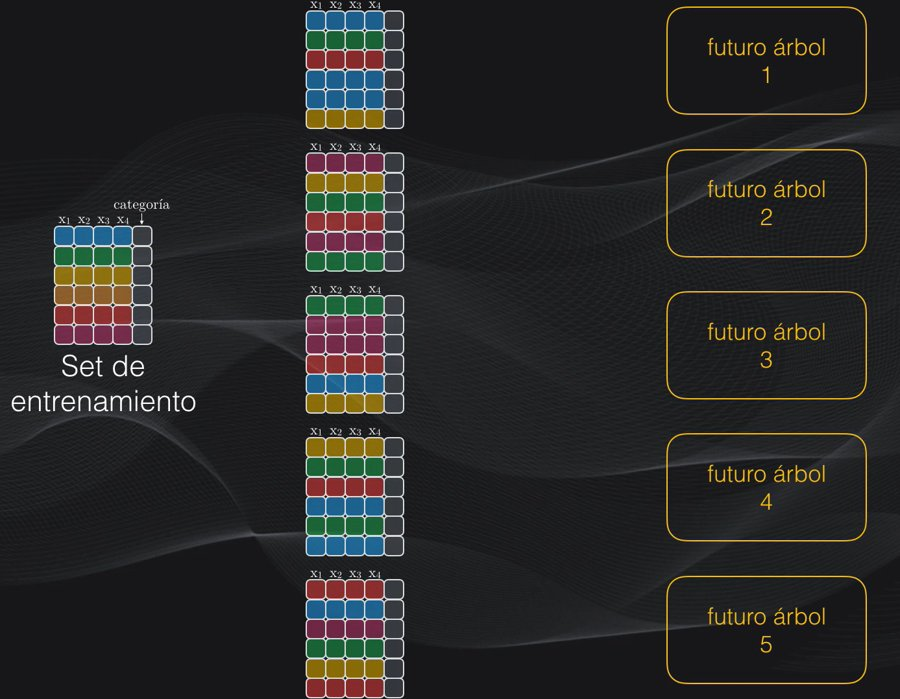

</center>
<center><figcaption><FONT SIZE=1 COLOR="black">Cada columna de la derecha es una muestra bootstrap distinta, tomada del mismo set de entrenamiento (izquierda). Fuente: codificandobits.com</FONT></figcaption></center>

#### Paso 2: Selección aleatoria de variables

Además de las filas, en cada división del árbol tampoco se evalúan todas las variables disponibles. Se elige al azar un subconjunto pequeño de ellas (En el ejemplo de las 4 variables originales $X_1, X_2, X_3, X_4$, esta división solo considera 2 por cada rama).

<center>

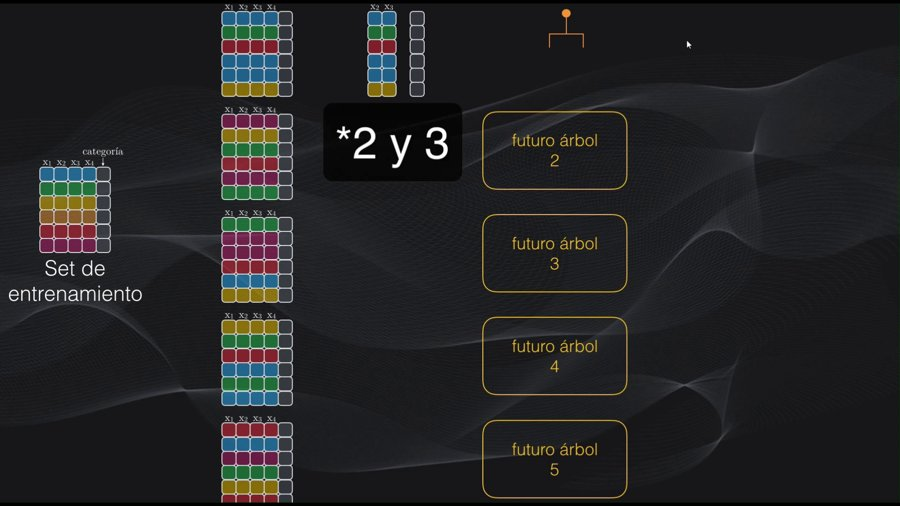

</center>
<center><figcaption><FONT SIZE=1 COLOR="black">Solo 2 de las 4 variables se evalúan como candidatas en esta división, esa es la segunda fuente de aleatoriedad del bosque. 
Fuente: codificandobits.com</FONT></figcaption></center>

¿Para qué sirve esto? Si todos los árboles pueden elegir entre todas las variables, la mayoría terminaría dividiendo primero por la más fuerte (`avaluo`, en nuestro caso) y árboles parecidos no aportan nada al promediar. Limitando las opciones, cada árbol explora un camino distinto.

Cuántas variables tomar en cada división es el hiperparámetro, `max_features`: puede ser un número fijo, una fracción del total, o raíz cuadrada del total, el valor clásico en clasificación.

Nota: en `scikit-learn`, el valor por defecto de `max_features` para `RandomForestRegressor` es `1.0`, es decir, en regresión esta aleatoriedad extra viene apagada por defecto, y el bosque depende solo del muestreo bootstrap del paso 1.

#### Paso 3: Cada muestra entrena su propio árbol

Repitiendo los pasos 1 y 2 en cada división, cada muestra bootstrap crece su propio árbol de decisión, de forma completamente independiente de los demás.

In [ ]:
# Animación completa del proceso (fuente: codificandobits.com)
from IPython.display import Video
Video("Video Project 3.mp4", embed=True, width=700)

**¿Las variables se pueden repetir entre distintas ramas?** Sí. La selección aleatoria de variables ocurre de forma independiente en cada división, no se gastan ni se eliminan después de usarse. Eso significa que una misma variable puede volver a salir sorteada en otra rama del mismo árbol, en otra división más abajo, o en los árboles de otras muestras.

#### Paso 4: Agregación: combinar las predicciones

Con todos los árboles ya entrenados, cada uno hace su propia predicción para un mismo caso nuevo.

<center>

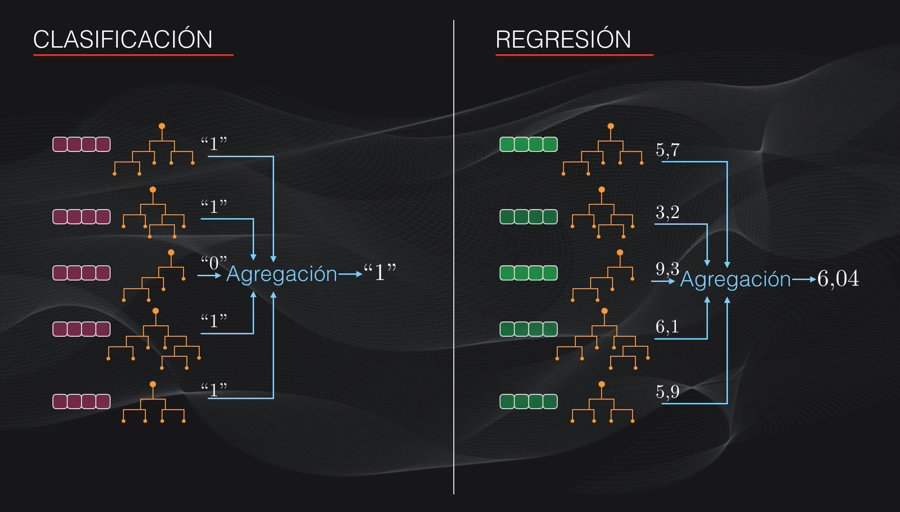

</center>
<center><figcaption><FONT SIZE=1 COLOR="black">Clasificación: se vota por la clase más frecuente. Regresión: se promedian los valores predichos por cada árbol. Fuente: codificandobits.com</FONT></figcaption></center>

Ahora que vimos el proceso completo, veamos numéricamente por qué promediar reduce el sobreajuste, con un ejemplo simple.

In [ ]:
rng = np.random.RandomState(42)
X_toy = np.sort(rng.uniform(0, 10, 60)).reshape(-1, 1)
y_toy = np.sin(X_toy).ravel() + rng.normal(0, 0.3, X_toy.shape[0])
X_plot = np.linspace(0, 10, 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_toy, y_toy, color="gray", alpha=0.5, label="Datos (con ruido)")

# 5 árboles individuales, cada uno entrenado con una muestra bootstrap distinta
for i in range(5):
    idx = rng.choice(len(X_toy), len(X_toy), replace=True)
    arbol = DecisionTreeRegressor(max_depth=4, random_state=i)
    arbol.fit(X_toy[idx], y_toy[idx])
    ax.plot(X_plot, arbol.predict(X_plot), alpha=0.4, linewidth=1, color="#E67E22",
            label="Árboles individuales" if i == 0 else None)

# Random Forest: el promedio de muchos árboles
rf_demo = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf_demo.fit(X_toy, y_toy)
ax.plot(X_plot, rf_demo.predict(X_plot), color="#1E8449", linewidth=3, label="Random Forest (promedio)")

ax.set_title("Por qué promediar árboles reduce el sobreajuste")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 6.1 — Interpretar el diagrama</p>

**a)** ¿Por qué las líneas naranjas (árboles individuales) son tan distintas entre sí, si todas vienen de los mismos datos originales?
`a)` Porque cada árbol se entrenó con una muestra bootstrap distinta (y posiblemente variables distintas en cada división)
`b)` Porque cada árbol usa una fórmula matemática diferente
`c)` Es un error del gráfico, deberían ser idénticas

**b)** ¿Por qué la línea verde (Random Forest) es más suave y se parece más a la curva real que cualquier línea naranja individual?
`a)` Porque promediar varias predicciones ruidosas cancela buena parte del ruido individual, dejando el patrón común
`b)` Porque Random Forest usa una ecuación distinta a la de los árboles
`c)` Es una coincidencia de este ejemplo

</div>

In [ ]:
respuesta_rf_diagrama_a = "?"
respuesta_rf_diagrama_b = "?"

verificar("rf_diagrama_a", respuesta_rf_diagrama_a)
verificar("rf_diagrama_b", respuesta_rf_diagrama_b)


## <FONT SIZE=4 COLOR="green"> 6.2 Hiperparámetros principales </FONT>

Los hiperparámetros más importantes de un Random Forest son:

<table style="border-collapse:collapse; width:100%;">
<thead><tr style="background-color:#1E8449; color:#ffffff;"><th style="padding:8px 12px; text-align:left;">Hiperparámetro</th><th style="padding:8px 12px; text-align:left;">Descripción</th></tr></thead>
<tbody>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>n_estimators</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Número de árboles en el bosque. Más árboles = predicciones más estables, pero más lento de entrenar.</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>max_depth</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Profundidad máxima de cada árbol individual (igual que en un árbol de decisión normal).</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>max_features</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Cuántas variables se toman como candidatas en cada división (Paso 2). Por defecto, se toman todas en regresión; raíz cuadrada del total en clasificación.</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>min_samples_leaf</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Mínimo de muestras en una hoja, igual que en un árbol individual.</td></tr>
</tbody>
</table>

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:8px 16px; margin:16px 0 0 0; border-radius:4px; font-size:14px;">
A diferencia de un árbol individual, Random Forest casi no necesita poda: el propio promedio entre árboles ya controla buena parte del sobreajuste. El hiperparámetro más influyente suele ser <code>n_estimators</code>.
</div>

## <FONT SIZE=4 COLOR="purple"> 6.3 Ejemplo: Random Forest sobre el dataset de apartamentos </FONT>

Usaremos las mismas seis variables predictoras que en la Regresión Lineal Múltiple (sección 5): `mt2`, `estrato`, `alcobas`, `banos`, `administracion` y `avaluo`. Así comparamos los dos modelos directamente sobre el mismo problema.

In [ ]:
# Mismas variables que en la regresión múltiple (sección 5)
X_rf = aptos[['mt2', 'estrato', 'alcobas', 'banos', 'administracion', 'avaluo']]
y_rf = aptos['precio']
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, random_state=1, test_size=0.2)


Entrenamos con 100 árboles y las demás opciones por defecto.

In [ ]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=1)
modelo_rf.fit(X_train_rf, y_train_rf)


Evaluamos su desempeño con las mismas métricas que usamos en los modelos lineales:

In [ ]:
y_pred_train_rf = modelo_rf.predict(X_train_rf)
y_pred_test_rf  = modelo_rf.predict(X_test_rf)

print("R2 entrenamiento:", r2_score(y_train_rf, y_pred_train_rf))
print("R2 prueba:        ", r2_score(y_test_rf, y_pred_test_rf))
print("RMSE prueba:       ", np.sqrt(mean_squared_error(y_test_rf, y_pred_test_rf)))


Visualicemos qué tan cerca están las predicciones de los valores reales, comparando cada predicción contra el precio real del apartamento:

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_rf, y_pred_test_rf, alpha=0.6, color="#1E8449")
lims = [min(y_test_rf.min(), y_pred_test_rf.min()), max(y_test_rf.max(), y_pred_test_rf.max())]
ax.plot(lims, lims, "k--", label="Predicción perfecta (y = x)")
ax.set_xlabel("Precio real")
ax.set_ylabel("Precio predicho")
ax.set_title("Random Forest: Predicho vs. Real (conjunto de prueba)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 6.2 — Detective: lee el gráfico</p>

Observa el gráfico de predicho vs. real que acabas de generar.

**a)** Si un modelo fuera perfecto, todos los puntos caerían exactamente sobre la línea punteada. ¿Qué significa un punto que está muy por encima de esa línea?
`a)` El modelo sobreestimó el precio real de ese apartamento
`b)` El modelo subestimó el precio real de ese apartamento
`c)` Ese apartamento no tiene precio real

</div>

In [ ]:
respuesta_rf_detective = "?"
verificar("rf_detective", respuesta_rf_detective)


Random Forest también nos dice qué variables usó con más frecuencia y con mayor efecto para dividir sus árboles, esto se llama importancia de variables.

In [ ]:
importancia_rf = pd.DataFrame({
    "variable": X_rf.columns,
    "importancia": modelo_rf.feature_importances_
}).sort_values("importancia", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(importancia_rf["variable"], importancia_rf["importancia"], color="#1E8449")
ax.bar_label(barras, fmt="%.3f", padding=4)
ax.invert_yaxis()
ax.set_xlim(0, importancia_rf["importancia"].max() * 1.15)
ax.set_title("Importancia de variables — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 6.3 — Importancia de variables</p>

**a)** Según el gráfico, ¿cuál es la variable más importante para predecir el precio? (escribe el nombre exacto de la columna, en minúsculas)

**b)** *(Reflexión, sin respuesta única)* ¿Tiene sentido que esa variable sea la más importante? Relaciónalo con lo que sabes sobre el mercado inmobiliario.

</div>

In [ ]:
respuesta_rf_importancia = "?"
verificar("rf_importancia_top", respuesta_rf_importancia)

# b) Tu reflexión (no se verifica automáticamente):
#


## <FONT SIZE=4 COLOR="green"> 6.4 Explora: el efecto de `n_estimators` </FONT>

Mueve el control deslizante para cambiar el número de árboles del bosque y observa cómo cambian las métricas. Necesitas ejecutar la celda para que aparezca el control.

In [ ]:
def explorar_n_estimators(n_estimators=100):
    modelo = RandomForestRegressor(n_estimators=n_estimators, random_state=1)
    modelo.fit(X_train_rf, y_train_rf)
    pred_train = modelo.predict(X_train_rf)
    pred_test  = modelo.predict(X_test_rf)
    print(f"n_estimators = {n_estimators}")
    print(f"R2 entrenamiento: {r2_score(y_train_rf, pred_train):.4f}")
    print(f"R2 prueba:        {r2_score(y_test_rf, pred_test):.4f}")
    print(f"RMSE prueba:      {np.sqrt(mean_squared_error(y_test_rf, pred_test)):.4f}")

widgets.interact(explorar_n_estimators, n_estimators=widgets.IntSlider(min=1, max=300, step=10, value=100));


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 6.4 — Experimenta con el slider</p>

Mueve el control entre valores pequeños (ej. 1-10) y grandes (ej. 200-300).

*(Reflexión, sin respuesta única)* ¿A partir de qué número de árboles las métricas dejan de mejorar significativamente? ¿Vale la pena seguir aumentando `n_estimators` más allá de ese punto?

</div>

<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Nota — Analogía con clasificación</p>

Todo lo visto en esta sección aplica igual para problemas de **clasificación**: en vez de `RandomForestRegressor` se usa `RandomForestClassifier`, y en vez de promediar las predicciones de los árboles, se toma la **clase más votada**. Los hiperparámetros (`n_estimators`, `max_depth`, `max_features`) son exactamente los mismos.

</div>

# <FONT SIZE=5 COLOR="purple"> 7. SVR (Máquinas de Vectores de Soporte para Regresión) </FONT>

El último modelo de la lista de la sección 2 es **SVR** (Support Vector Regression), la versión para regresión de las Máquinas de Vectores de Soporte (SVM). A diferencia de Random Forest, que construye su predicción combinando muchos árboles, SVR busca una única función que se ajuste a los datos dejando el menor error posible dentro de un margen de tolerancia.

Para entenderlo, primero repasemos la idea general de SVM (pensada originalmente para clasificación), y luego veremos cómo se adapta a regresión.

## <FONT SIZE=4 COLOR="green"> 7.1 Intuición: clasificación binaria con el margen más amplio </FONT>

El uso más común de las Máquinas de Vectores de Soporte (SVM) es la clasificación binaria: separar un conjunto de datos en dos categorías distintas (por ejemplo, tiene enfermedad / no tiene enfermedad, como hicimos con árboles en la sesión anterior). Antes de llegar a la versión para regresión (SVR), vale la pena entender bien esta idea original.

A diferencia de otros clasificadores que solo buscan alguna línea que separe las clases, una SVM busca específicamente la línea (o plano, en más dimensiones) que deja el margen más amplio posible a cada lado, como trazar la carretera más ancha posible entre dos grupos de puntos, sin tocar a ninguno.

Las siguientes imágenes ilustran esto con un ejemplo de ciclismo: clasificar corredores en *escaladores* (especialistas en montaña) vs. *embaladores* (especialistas en terreno plano), según su peso (eje X) y la potencia que desarrollan en cada pedalazo (eje Y).

<br>
<center><img src="https://codificandobits.com/media/margen-maquinas-de-soporte-vectorial.png" alt="Margen de una SVM" width="550"></center>
<center><figcaption><FONT SIZE=1 COLOR="black">Fuente: codificandobits.com — Máquinas de Soporte Vectorial</FONT></figcaption></center>
<br>

Los **vectores de soporte** son los puntos más cercanos al límite del margen, son los que realmente determinan dónde queda el hiperplano. Si movieras cualquier otro punto lejos del margen, el hiperplano no cambiaría; pero si mueves un vector de soporte, el hiperplano sí se recalcula.

<br>
<center><img src="https://codificandobits.com/media/vectores-de-soporte.png" alt="Vectores de soporte" width="550"></center>
<center><figcaption><FONT SIZE=1 COLOR="black">Fuente: codificandobits.com — Máquinas de Soporte Vectorial</FONT></figcaption></center>
<br>

**Hard margin vs. soft margin**

La versión más estricta (*hard margin*) exige que ningún punto quede dentro del margen ni del lado equivocado de la línea. Esto solo funciona si los datos son perfectamente separables, y es muy sensible a valores atípicos: un solo punto mal ubicado puede forzar un margen diminuto, o hacer que no exista ninguna solución posible.

<center><img src="https://codificandobits.com/media/hard-margin-y-coeficientes.png" alt="Hard margin" width="550"></center>
<center><figcaption><FONT SIZE=1 COLOR="black">Fuente: codificandobits.com — Máquinas de Soporte Vectorial</FONT></figcaption></center>


En la práctica casi siempre se usa la versión *soft margin*, que permite que algunos puntos violen el margen o incluso queden del lado equivocado a cambio de un margen más ancho y un modelo más generalizable. Qué tan tolerante es ese margen lo controla el hiperparámetro **C**: un `C` pequeño permite más violaciones (margen más ancho, modelo más simple); un `C` grande penaliza fuertemente cualquier violación (margen más angosto, más ajustado a los datos de entrenamiento, con riesgo de sobreajuste).

<center><img src="https://codificandobits.com/media/parametro-c-soft-margin.gif" alt="Efecto del parámetro C" width="550"></center>
<center><figcaption><FONT SIZE=1 COLOR="black">Fuente: codificandobits.com — Máquinas de Soporte Vectorial</FONT></figcaption></center>

<center><img src="https://codificandobits.com/media/grafica-error-vs-c.png" alt="Error vs. C" width="550"></center>
<center><figcaption><FONT SIZE=1 COLOR="black">Fuente: codificandobits.com — Máquinas de Soporte Vectorial</FONT></figcaption></center>

**¿Y cuándo los datos no se pueden separar con una línea recta?**

Hay conjuntos de datos donde, sin importar qué tan flexible sea el margen, ninguna línea recta (ni plano) logra separar las clases suficientemente bien, por ejemplo, cuando una clase forma un anillo alrededor de la otra. Ahí es donde entra el **truco del kernel**.

**El truco del kernel**

La idea: si los datos no son separables linealmente en su espacio original, los transformamos a un espacio de **más dimensiones**, donde sí lo son.

<br>
<center><img src="https://codificandobits.com/media/truco-del-kernel-transformacion.png" alt="Truco del kernel" width="600"></center>
<center><figcaption><FONT SIZE=1 COLOR="black">Fuente: codificandobits.com — Máquinas de Soporte Vectorial</FONT></figcaption></center>
<br>

Por ejemplo, un patrón circular en 2D (imposible de separar con una línea) se vuelve separable al agregar una tercera dimensión. Calcular esa transformación explícitamente sería muy costoso si el espacio de destino tiene muchas dimensiones, el truco es que existen funciones matemáticas (los *kernels*) que calculan el resultado de esa transformación sin construirla explícitamente, ahorrando muchísimo cómputo. Los más usados:

- `linear`: no transforma nada; asume que los datos ya son separables en el espacio original.
- `poly` (polinomial): crea fronteras curvas de orden *n*.
- `rbf` (radial / gaussiano): el más flexible, puede crear fronteras de forma muy irregular, es el que usaremos por defecto.

**Importante:** *hard margin* / *soft margin*, y la pregunta de cuándo ya no se puede separar con una línea recta, son ideas que nacen en el contexto de **clasificación**. En regresión (SVR), el concepto de margen se transforma en el tubo de tolerancia que veremos a continuación, pero el hiperparámetro `C` y el truco del kernel se mantienen exactamente iguales.

<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 7.1 — Margen y kernel</p>

**a)** Si entrenas una SVM y luego eliminas un punto que **no** es vector de soporte, ¿qué le pasa al hiperplano?
`a)` No cambia
`b)` Cambia completamente
`c)` El modelo deja de funcionar

**b)** Si usas un `C` muy grande (soft margin casi tan estricto como hard margin) sobre datos con algunos valores atípicos, ¿qué es más probable que ocurra?
`a)` El modelo se ajusta demasiado a esos valores atípicos y generaliza peor (sobreajuste)
`b)` El modelo ignora completamente a los valores atípicos
`c)` No tiene ningún efecto

</div>

In [ ]:
respuesta_svr_margen_a = "?"
respuesta_svr_margen_b = "?"

verificar("svr_margen_a", respuesta_svr_margen_a)
verificar("svr_margen_b", respuesta_svr_margen_b)


## <FONT SIZE=4 COLOR="green"> 7.2 De clasificación a regresión: el tubo de tolerancia (epsilon) </FONT>

En **regresión**, la idea del margen se invierte: en vez de buscar la línea que separa dos clases dejando el margen más ancho, SVR busca la línea que **pasa por el centro de un "tubo"**, de manera que la mayor cantidad de puntos caigan dentro de él.

El ancho de ese tubo se controla con el hiperparámetro **epsilon ($\varepsilon$)**:

- Los puntos que caen dentro del tubo (a una distancia menor que $\varepsilon$ de la línea) se consideran "suficientemente bien predichos" y no penalizan al modelo.
- Los puntos que caen fuera del tubo sí generan error, y son los que se convierten en vectores de soporte: son ellos los que determinan la forma final de la línea.

Veámoslo con un ejemplo simple.

In [ ]:
rng = np.random.RandomState(7)
X_toy2 = np.sort(rng.uniform(0, 10, 40)).reshape(-1, 1)
y_toy2 = 0.5 * X_toy2.ravel() + rng.normal(0, 0.6, X_toy2.shape[0])

svr_demo = SVR(kernel="linear", epsilon=0.8)
svr_demo.fit(X_toy2, y_toy2)
X_plot2 = np.linspace(0, 10, 200).reshape(-1, 1)
y_line = svr_demo.predict(X_plot2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_toy2, y_toy2, color="gray", alpha=0.6, label="Datos")
ax.plot(X_plot2, y_line, color="#2471A3", linewidth=2, label="Línea de predicción")
ax.fill_between(X_plot2.ravel(), y_line - 0.8, y_line + 0.8, color="#2471A3", alpha=0.15,
                label="Tubo de tolerancia (epsilon = 0.8)")

sv_idx = svr_demo.support_
ax.scatter(X_toy2[sv_idx], y_toy2[sv_idx], color="#E67E22", s=80, edgecolor="black",
           zorder=5, label="Vectores de soporte")

ax.set_title("SVR: el tubo de tolerancia (epsilon) y los vectores de soporte")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Número de vectores de soporte: {len(sv_idx)} de {len(X_toy2)} puntos totales")


<div style="background-color:#EAF2F8; border-left:4px solid #2471A3; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 7.2 — Interpretar el tubo</p>

**a)** Si en lugar de `epsilon = 0.8` usáramos un `epsilon` mucho más grande (ej. 3.0), ¿qué pasaría con el número de vectores de soporte?
`a)` Disminuiría (el tubo más ancho deja a más puntos "dentro", tolerados)
`b)` Aumentaría
`c)` No cambiaría

</div>

In [ ]:
respuesta_svr_epsilon_a = "?"
verificar("svr_epsilon_a", respuesta_svr_epsilon_a)


## <FONT SIZE=4 COLOR="green"> 7.3 Hiperparámetros principales </FONT>

Antes de entrenar un SVR, formalicemos los tres hiperparámetros que acabamos de discutir:

<table style="border-collapse:collapse; width:100%;">
<thead><tr style="background-color:#1E8449; color:#ffffff;"><th style="padding:8px 12px; text-align:left;">Hiperparámetro</th><th style="padding:8px 12px; text-align:left;">Descripción</th></tr></thead>
<tbody>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>kernel</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Función usada para transformar el espacio cuando los datos no son separables linealmente: 'linear', 'rbf' (radial, la más común), 'poly'. Ver sección 7.1.</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>C</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Qué tan estricto es el margen/tubo (soft margin). C grande = modelo más ajustado a los datos de entrenamiento (puede sobreajustar); C pequeño = modelo más tolerante y simple.</td></tr>
<tr><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;"><code>epsilon</code></td><td style="padding:8px 12px; border-bottom:1px solid #e5e5e5;">Ancho del tubo de tolerancia (solo en regresión). Controla cuántos puntos quedan 'dentro' sin penalizar. Ver sección 7.2.</td></tr>
</tbody>
</table>

## <FONT SIZE=4 COLOR="purple"> 7.4 Un detalle importante: escalar los datos </FONT>

A diferencia de los árboles de decisión y Random Forest que dividen el espacio con base en umbrales, sin importar la escala de las variables, SVR calcula distancias entre puntos para encontrar el mejor ajuste. Si una variable está en una escala mucho mayor que las demás (por ejemplo, `avaluo` en millones vs. `estrato` de 1 a 6), domina el cálculo de distancias y el modelo prácticamente ignora a las demás variables.

Por eso, siempre se debe escalar los datos antes de entrenar un SVR (normalmente con `StandardScaler`).

<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 7.4 — Encuentra el error</p>

El siguiente código entrena un SVR, pero el resultado es sorprendentemente malo. **Ejecútalo primero tal cual, sin modificarlo**, y observa el $R^2$.

```python
X_svr = aptos[['mt2', 'estrato', 'alcobas', 'banos', 'administracion', 'avaluo']]
y_svr = aptos['precio']
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_svr, y_svr, random_state=1, test_size=0.2)

svr_malo = SVR(kernel="rbf")
svr_malo.fit(X_train_svr, y_train_svr)
y_pred_malo = svr_malo.predict(X_test_svr)

print("R2 de prueba (SIN escalar):", r2_score(y_test_svr, y_pred_malo))
```

</div>

In [ ]:
X_svr = aptos[['mt2', 'estrato', 'alcobas', 'banos', 'administracion', 'avaluo']]
y_svr = aptos['precio']
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_svr, y_svr, random_state=1, test_size=0.2)

svr_malo = SVR(kernel="rbf")
svr_malo.fit(X_train_svr, y_train_svr)
y_pred_malo = svr_malo.predict(X_test_svr)

print("R2 de prueba (SIN escalar):", r2_score(y_test_svr, y_pred_malo))


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

**a)** ¿Cuál es el diagnóstico del problema?
`a)` SVR usa distancias, y `avaluo`/`administracion` (en una escala mucho mayor) dominan el cálculo frente a variables como `estrato` o `banos`
`b)` El dataset tiene valores nulos
`c)` El modelo necesita más datos de entrenamiento

**b)** Ahora corrígelo tú: completa el código de abajo (reemplaza cada `...`) agregando un `StandardScaler` que escale tanto `X` como `y` antes de entrenar. Recuerda que, al final, debes revertir la escala de las predicciones con `scaler_y.inverse_transform(...)` antes de calcular el $R^2$ (porque el precio real está en la escala original, no en la escalada).

Compara el nuevo $R^2$ con el anterior:
`a)` Prácticamente igual
`b)` Un poco mejor
`c)` Mucho mejor

</div>

In [ ]:
respuesta_svr_bug_diagnostico = "?"
verificar("svr_bug_diagnostico", respuesta_svr_bug_diagnostico)

# Completa tú (reemplaza cada ...):
scaler_X = ...   # StandardScaler().fit(X_train_svr)
scaler_y = ...   # StandardScaler().fit(y_train_svr.values.reshape(-1, 1))

X_train_svr_s = ...   # scaler_X.transform(X_train_svr)
X_test_svr_s  = ...   # scaler_X.transform(X_test_svr)
y_train_svr_s = ...   # scaler_y.transform(y_train_svr.values.reshape(-1, 1)).ravel()

if Ellipsis in (scaler_X, scaler_y) or isinstance(X_train_svr_s, type(Ellipsis)) \
   or isinstance(X_test_svr_s, type(Ellipsis)) or isinstance(y_train_svr_s, type(Ellipsis)):
    raise ValueError("Todavía te falta completar alguna de las líneas marcadas con '...' arriba (antes de entrenar el modelo).")

svr_bueno = SVR(kernel="rbf")
svr_bueno.fit(X_train_svr_s, y_train_svr_s)

y_pred_bueno_s = svr_bueno.predict(X_test_svr_s)
y_pred_bueno   = ...   # scaler_y.inverse_transform(y_pred_bueno_s.reshape(-1, 1)).ravel()

if isinstance(y_pred_bueno, type(Ellipsis)):
    raise ValueError("Todavía te falta completar la línea de y_pred_bueno (revertir la escala de la predicción).")

print("R2 de prueba (escalado):", r2_score(y_test_svr, y_pred_bueno))

respuesta_svr_bug_mejora = "?"
verificar("svr_bug_mejora", respuesta_svr_bug_mejora)


## <FONT SIZE=4 COLOR="green"> 7.5 Explora: el efecto de `epsilon` </FONT>

Mueve el control deslizante para cambiar el ancho del tubo de tolerancia y observa el efecto sobre el $R^2$ y el número de vectores de soporte, usando el modelo ya escalado del ejercicio anterior.

In [ ]:
def explorar_epsilon(epsilon=0.1):
    modelo = SVR(kernel="rbf", C=1.0, epsilon=epsilon)
    modelo.fit(X_train_svr_s, y_train_svr_s)
    pred_s = modelo.predict(X_test_svr_s)
    pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    print(f"epsilon = {epsilon}")
    print(f"R2 de prueba:              {r2_score(y_test_svr, pred):.4f}")
    print(f"Número de vectores de soporte: {len(modelo.support_)}")

widgets.interact(explorar_epsilon, epsilon=widgets.FloatSlider(min=0.01, max=2.0, step=0.01, value=0.1));


<div style="background-color:#EAFAF1; border-left:4px solid #1E8449; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 7.4 — Experimenta con epsilon</p>

Mueve el control entre valores pequeños (0.01) y grandes (cerca de 2.0).

**a)** Con `epsilon = 2.0`, el $R^2$ de prueba es aproximadamente:

</div>

In [ ]:
respuesta_svr_epsilon_b = "?"
verificar("svr_epsilon_b", respuesta_svr_epsilon_b)

# ¿Qué está pasando ahí? (no se verifica automáticamente, piénsalo con tus propias palabras):
#


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Nota: Analogía con clasificación</p>

El mismo modelo tiene una versión para clasificación: **SVC** (*Support Vector Classifier*). Comparte los mismos hiperparámetros (`kernel`, `C`) y el mismo truco del kernel para fronteras no lineales, la diferencia es que, en vez de ajustar una línea dentro de un tubo de tolerancia, busca el hiperplano que separa las clases con el margen más ancho, como vimos al inicio de la sección 7.1.

</div>

# <FONT SIZE=5 COLOR="purple"> 8. Comparación final de los 4 modelos </FONT>

Ya entrenamos cuatro enfoques distintos para predecir el precio de un apartamento: Regresión Lineal Simple, Regresión Lineal Múltiple, Random Forest y SVR. Comparemos su desempeño sobre el mismo conjunto de prueba.

In [ ]:
resultados = []

# 1. Lineal simple (solo mt2)
# Nota: las variables X_test/y_test de la sección 4 fueron reutilizadas (y
# sobrescritas) en la sección 5 con el dataset "ventas". Recreamos aquí el
# mismo split (misma semilla y proporción) para evaluar correctamente a modelo_rl.
X_simple = aptos[["mt2"]]
y_simple = aptos[["precio"]]
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, random_state=1, test_size=0.2
)
pred_simple = modelo_rl.predict(X_test_simple)
resultados.append({
    "Modelo": "Lineal simple",
    "R2 prueba": r2_score(y_test_simple, pred_simple),
    "RMSE prueba": np.sqrt(mean_squared_error(y_test_simple, pred_simple)),
})

# 2. Lineal múltiple
pred_multiple = modelo_multiple.predict(X_test_m)
resultados.append({
    "Modelo": "Lineal múltiple",
    "R2 prueba": r2_score(y_test_m, pred_multiple),
    "RMSE prueba": np.sqrt(mean_squared_error(y_test_m, pred_multiple)),
})

# 3. Random Forest
resultados.append({
    "Modelo": "Random Forest",
    "R2 prueba": r2_score(y_test_rf, y_pred_test_rf),
    "RMSE prueba": np.sqrt(mean_squared_error(y_test_rf, y_pred_test_rf)),
})

# 4. SVR (escalado)
resultados.append({
    "Modelo": "SVR (escalado)",
    "R2 prueba": r2_score(y_test_svr, y_pred_bueno),
    "RMSE prueba": np.sqrt(mean_squared_error(y_test_svr, y_pred_bueno)),
})

tabla_comparativa = pd.DataFrame(resultados).set_index("Modelo").round(4)
tabla_comparativa


<div style="background-color:#F5EEF8; border-left:4px solid #6A0DAD; padding:10px 18px; margin:8px 0; border-radius:4px; font-size:14px;">

<p style="font-size:15px; font-weight:600; margin:0 0 8px 0;">Ejercicio 8.1 — Interpretar la comparación</p>

**a)** ¿Cuál modelo tiene el mejor $R^2$ de prueba?
`a)` Lineal simple &nbsp; `b)` Lineal múltiple &nbsp; `c)` Random Forest &nbsp; `d)` SVR (escalado)

**b)** *(Reflexión, sin respuesta única)* Si tuvieras que explicarle a un cliente no técnico por qué el modelo más simple (lineal) no es el mejor aquí, ¿qué le dirías?

**c)** *(Reflexión, sin respuesta única)* Random Forest y SVR superaron a la regresión lineal múltiple. ¿Qué tienen en común estos dos modelos que les permite capturar relaciones que la regresión lineal no puede? Piensa en el concepto de "relaciones no lineales".

</div>

In [ ]:
respuesta_comparacion_mejor = "?"
verificar("comparacion_mejor", respuesta_comparacion_mejor)

# b) Tu explicación (no se verifica automáticamente):
#

# c) Tu reflexión (no se verifica automáticamente):
#


# <FONT SIZE=5 COLOR="green"> 9. Resumen </FONT>

En este notebook trabajamos cuatro enfoques para resolver un problema de **regresión** (predecir el precio de un apartamento):

1. **Regresión Lineal Simple**: una sola variable predictora, encuentra la línea que minimiza la suma de errores al cuadrado (mínimos cuadrados).

2. **Regresión Lineal Múltiple**: extiende la idea anterior a varias variables predictoras simultáneamente.

3. **Random Forest**: combina muchos árboles de decisión entrenados con muestras distintas (bagging), promediando sus predicciones para reducir el sobreajuste de un árbol individual.

4. **SVR**: busca la función que pasa por el centro de un "tubo de tolerancia" (controlado por `epsilon`), minimizando qué tanto se desvían los puntos fuera de ese tubo. Requiere escalar los datos.

**Regla general:** los modelos lineales son los más simples e interpretables, pero cuando la relación entre las variables y el objetivo no es lineal, modelos como Random Forest o SVR suelen capturar mejor esos patrones — a cambio de ser más difíciles de interpretar directamente.

Todo lo que vimos aquí para regresión tiene su versión análoga para **clasificación** (`RandomForestClassifier`, `SVC`), cambiando la variable objetivo de un número continuo a una categoría, y la forma de combinar predicciones (promedio → votación).